<a id="top"></a>
# Chapter 5 — X-ray data and the Bragg profile

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 5 of 10

[◀ 4 Fitting neutron F(Q) and G(r) with RMCProfile](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [Contents of the book](README.md) · [6 Constraints, restraints and potentials ▶](RMCProfile_06_Constraints_and_Potentials.ipynb)

**In this chapter**

- [§19 X-rays see electrons: the form factor](#sec-19)
- [§20 Contrast: the same box, two radiations](#sec-20)
- [§21 An X-ray run of RMCProfile, and what it does not confirm](#sec-21)
- [§22 Bragg profiles: the long-range order](#sec-22)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 10}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 5")
t_chapter_start = time.time()

rmcprofile-skill 0.3.0 | numpy 2.5.2 | RMCProfile package: windows build | chapter 5


<a id="sec-19"></a>

## 19. X-rays see electrons: the form factor

A neutron's scattering length $b$ is a constant per isotope; an X-ray's is the atomic form
factor $f(Q)$, the Fourier transform of the electron cloud — $f(0) = Z$ electrons and a
decay with $Q$ that is faster for the diffuse valence shell than for the core. RMCProfile
takes $f(Q)$ from a `.xray` file with one line per element, the nine Cromer–Mann
coefficients `a1 b1 a2 b2 a3 b3 a4 b4 c` of $f(s) = \sum_k a_k e^{-b_k s^2} + c$, $s = Q/4\pi$
(manual §4.3). The toolkit computes $f(Q)$ from the BSD-licensed `periodictable` tables
and fits that four-Gaussian form, so a `.xray` file can be written for any element.

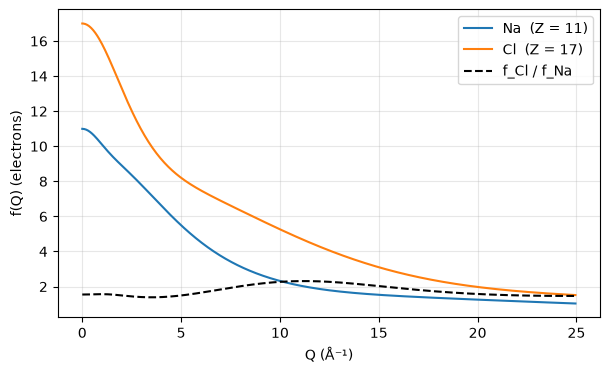

[PASS] f(0) = Z for both elements (Cromer–Mann sum, to 0.1 electron) — 10.994, 17.000


Cl four-Gaussian fit residual: max 0.0001 electrons
[PASS] the four-term fit reproduces f(Q) to 0.05 electron over 0–25 Å⁻¹
NA    4.9022    3.2582    3.1106    9.0803    1.4049    0.2339    1.0996  131.9086    0.4763
CL    6.9692    1.1871    6.1495   18.3364    1.2113    0.2074    1.7533   46.3661    0.9165



In [2]:
q = np.arange(0.0, 25.0, 0.05)
f_na, f_cl = rt.xray_form_factor("Na", q), rt.xray_form_factor("Cl", q)
fig, ax = plt.subplots()
ax.plot(q, f_na, label="Na  (Z = 11)")
ax.plot(q, f_cl, label="Cl  (Z = 17)")
ax.plot(q, f_cl / f_na, "k--", label="f_Cl / f_Na")
ax.set_xlabel("Q (Å⁻¹)"); ax.set_ylabel("f(Q) (electrons)"); ax.legend()
show(fig)
caption("X-ray atomic form factors of Na and Cl from the Cromer–Mann tables: Z electrons "
        "at Q = 0, falling with Q; the ratio between them is not constant, so an X-ray F(Q) "
        "mixes the partials with Q-dependent weights.")
check("f(0) = Z for both elements (Cromer–Mann sum, to 0.1 electron)", abs(f_na[0] - 11) < 0.1 and abs(f_cl[0] - 17) < 0.1,
      f"{f_na[0]:.3f}, {f_cl[0]:.3f}")
coef = rt.cromer_mann_4term("Cl")
s = q / (4 * np.pi)
f_fit = sum(coef[2 * k] * np.exp(-coef[2 * k + 1] * s * s) for k in range(4)) + coef[8]
print("Cl four-Gaussian fit residual: max", f"{np.max(np.abs(f_fit - f_cl)):.4f}", "electrons")
check("the four-term fit reproduces f(Q) to 0.05 electron over 0–25 Å⁻¹", np.max(np.abs(f_fit - f_cl)) < 0.05)
rt.write_xray_file(os.path.join(WORK, "nacl.xray"), ["Na", "Cl"])
with open(os.path.join(WORK, "nacl.xray"), encoding="utf-8") as fh:
    print(fh.read())

<a id="sec-20"></a>

## 20. Contrast: the same box, two radiations

With Keen's neutron $G(r)$ every partial enters with the constant weight $c_i c_j b_i b_j$;
Na and Cl scatter neutrons with 3.63 and 9.58 fm, so Cl–Cl dominates. With X-rays the
weights are $c_i c_j f_i(Q) f_j(Q)$ normalised by $(\sum c f)^2$ — RMCProfile's default
`NORMALIZATION_TYPE :: <f^2>` divides by $\sum c f^2$ instead, a second convention the
data reduction must match — and they change along $Q$. The toolkit builds either total
from the same partials (`total_fq_from_partials`, `radiation="neutron"` or `"xray"`), so
the contrast can be looked at directly.

neutron weights (barn): {'Na-Na': 0.0329, 'Na-Cl': 0.1738, 'Cl-Cl': 0.2293}
X-ray weights at Q = 1 and Q = 20 Å⁻¹: {'Na-Na': (np.float64(0.152), np.float64(0.151)), 'Na-Cl': (np.float64(0.476), np.float64(0.475)), 'Cl-Cl': (np.float64(0.373), np.float64(0.374))}


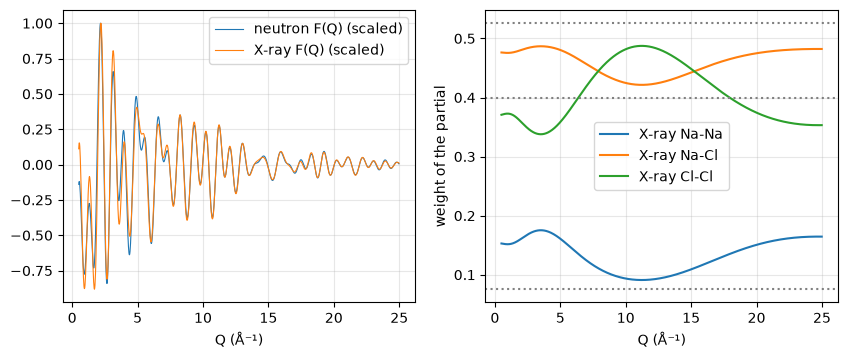

[PASS] the X-ray weights sum to one at every Q
[PASS] Cl–Cl carries most of the neutron signal but not of the X-ray one at Q = 1 Å⁻¹


True

In [3]:
NACL = [("Na", 0, 0, 0), ("Na", .5, .5, 0), ("Na", .5, 0, .5), ("Na", 0, .5, .5),
        ("Cl", .5, 0, 0), ("Cl", 0, .5, 0), ("Cl", 0, 0, .5), ("Cl", .5, .5, .5)]
A = 5.64
cfg = rt.build_configuration((A, A, A, 90, 90, 90), NACL, (3, 3, 3), title="NaCl 3x3x3")
rng = np.random.default_rng(0)
truth = rl.Box.from_rmc6f(cfg)
truth.frac = (truth.frac + rng.normal(0, 0.05, truth.frac.shape) / cfg.cell[0]) % 1.0
r, g_truth, G_truth = rl.synth_targets(truth, rmax=8.0, dr=0.02, noise=0.0, rng=rng)
qq = np.arange(0.5, 25.0, 0.02)
F_n = rt.total_fq_from_partials(r, g_truth, cfg, qq, radiation="neutron")
F_x = rt.total_fq_from_partials(r, g_truth, cfg, qq, radiation="xray")
w_n = rt.neutron_weights(cfg)
w_x = rt.xray_weights(cfg, qq)
print("neutron weights (barn):", {k: round(v, 4) for k, v in w_n.items()})
print("X-ray weights at Q = 1 and Q = 20 Å⁻¹:", {k: (round(v[25], 3), round(v[-250], 3)) for k, v in w_x.items()})
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(qq, F_n / np.abs(F_n).max(), lw=0.8, label="neutron F(Q) (scaled)")
axes[0].plot(qq, F_x / np.abs(F_x).max(), lw=0.8, label="X-ray F(Q) (scaled)")
axes[0].set_xlabel("Q (Å⁻¹)"); axes[0].legend()
for k, v in w_x.items():
    axes[1].plot(qq, v, label=f"X-ray {k}")
for k, v in w_n.items():
    axes[1].axhline(v / sum(w_n.values()), ls=":", color="gray")
axes[1].set_xlabel("Q (Å⁻¹)"); axes[1].set_ylabel("weight of the partial"); axes[1].legend()
show(fig)
caption("Left: the neutron and X-ray total scattering functions of the same thermal NaCl box. "
        "Right: the X-ray weights of the three partials along Q (solid) and the neutron ones "
        "(dotted, normalised): X-rays weigh Cl–Cl less and Na–Cl more than neutrons do, and "
        "the balance drifts with Q.")
check("the X-ray weights sum to one at every Q", np.allclose(sum(w_x.values()), 1.0))
check("Cl–Cl carries most of the neutron signal but not of the X-ray one at Q = 1 Å⁻¹",
      w_n["Cl-Cl"] / sum(w_n.values()) > 0.5 and w_x["Cl-Cl"][25] < 0.5)

<a id="sec-21"></a>

## 21. An X-ray run of RMCProfile, and what it does not confirm

The `XRAY_RECIPROCAL_SPACE_DATA ::` block takes the same subordinate keywords as the neutron
one plus the `.xray` file beside the configuration. Write the synthetic X-ray $F(Q)$ with
the toolkit's normalisation, run the ideal lattice against it at `TIME_LIMIT 0` and compare
RMCProfile's calculated column with ours. Honesty first: the *experiment* column returns our
data exactly, the program runs and reports χ², and the calculated column has our scale
(median ratio 1.00) — but its shape agrees with our $(\sum c f)^2$-normalised function only
to a correlation of 0.90, and neither `NORMALIZATION_TYPE` value changes it. Which further
processing RMCProfile applies to X-ray $F(Q)$ this book has not reproduced (finding N-8,
a question for the mailing list); the neutron functions of chapter 4 are reproduced to
single precision.

checker: ['no-weight']


rc 0 | chi2: {'m_accepted': 0, 'm_generated': 1, 'm_tested': 0, 'chi2': 1289.0, 'Expt_1': 1289.0} | outputs: ['nx_FQ1.csv', 'nx_FQ1partials.csv', 'nx_PDFpartials.csv', 'nx_XFQ1.csv']
experiment column vs our data: max|diff| = 5.0e-09
calculated column vs our (sum c f)^2-normalised F(Q) of the same ideal lattice: correlation 0.901, median ratio 0.999


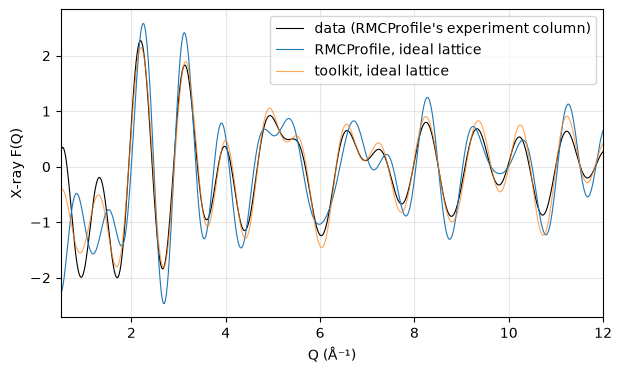

[PASS] RMCProfile ran the X-ray set and wrote its XFQ output
[PASS] the experiment column is our data (no convolution asked)
[PASS] the calculated column has our scale (median ratio within 3 %) — 0.999
[PASS] its shape correlates with ours at 0.85 or better — and that is all this book can claim — 0.901


In [4]:
if not skip_without_package("the X-ray run"):
    work = os.path.join(WORK, "xray")
    os.makedirs(work, exist_ok=True)
    rt.write_data_file(os.path.join(work, "nx_xfq.dat"), qq, F_x, "synthetic X-ray F(Q)")
    rt.write_xray_file(os.path.join(work, "nx.xray"), ["Na", "Cl"])
    xblock = rt.DatBlock("XRAY_RECIPROCAL_SPACE_DATA", "1", [
        ("FILENAME", "nx_xfq.dat"), ("DATA_TYPE", "F(Q)"), ("FIT_TYPE", "F(Q)"), ("NO_FITTED_SCALE", None),
        ("RECIPROCAL_SPACE_FIT", "1 %d 1" % len(qq)), ("RECIPROCAL_SPACE_PARAMETERS", "1 %d 0.01" % len(qq))])
    rt.write_input_set("nx", work, cfg, min_dist={"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0}, max_move=0.05,
                       time_limit_min=0.0, extra_blocks=[xblock], title="synthetic NaCl, X-ray")
    findings = rt.check_input_set("nx", work)
    print("checker:", [f.code for f in findings if f.level != "INFO"] or "clean")
    res = rt.run_rmcprofile("nx", work, PKG, timeout_min=3)
    print("rc", res.returncode, "| chi2:", res.final_chi2, "| outputs:", [o for o in res.outputs if o.endswith(".csv")])
    x, calc, expt = rt.read_csv_pair(os.path.join(work, "nx_XFQ1.csv"))
    F_x_ideal = rt.total_fq_from_partials(r, rt.partial_gr(cfg, rmax=8.0, dr=0.02)[1], cfg, qq, radiation="xray")
    corr = np.corrcoef(calc, F_x_ideal)[0, 1]
    ratio = np.median(calc[10:300] / F_x_ideal[10:300])
    print(f"experiment column vs our data: max|diff| = {np.max(np.abs(expt - F_x)):.1e}")
    print(f"calculated column vs our (sum c f)^2-normalised F(Q) of the same ideal lattice: correlation {corr:.3f}, median ratio {ratio:.3f}")
    fig, ax = plt.subplots()
    ax.plot(x, expt, "k", lw=0.8, label="data (RMCProfile's experiment column)")
    ax.plot(x, calc, lw=0.8, label="RMCProfile, ideal lattice")
    ax.plot(qq, F_x_ideal, lw=0.8, alpha=0.7, label="toolkit, ideal lattice")
    ax.set_xlim(0.5, 12); ax.set_xlabel("Q (Å⁻¹)"); ax.set_ylabel("X-ray F(Q)"); ax.legend()
    show(fig)
    caption("RMCProfile's X-ray F(Q) of the ideal NaCl lattice against the toolkit's for the same "
            "box and the synthetic data: same scale and peak positions, a shape that agrees only "
            "in part — the open question of finding N-8.")
    check("RMCProfile ran the X-ray set and wrote its XFQ output", res.returncode == 0 and "nx_XFQ1.csv" in res.outputs)
    check("the experiment column is our data (no convolution asked)", np.max(np.abs(expt - F_x)) < 1e-4)
    check("the calculated column has our scale (median ratio within 3 %)", abs(ratio - 1) < 0.03, f"{ratio:.3f}")
    check("its shape correlates with ours at 0.85 or better — and that is all this book can claim", corr > 0.85, f"{corr:.3f}")

<a id="sec-22"></a>

## 22. Bragg profiles: the long-range order

The total scattering data of chapters 1–4 carry the local structure; the Bragg peaks carry
the average one, and RMCProfile is the RMC code that fits both (Tucker et al. 2007). The
`BRAGG ::` block needs four files a Rietveld program produces (manual §4.11–4.13): the
profile itself (`.bragg`, one bank, time-of-flight against intensity), the background
coefficients (`.back`), the GSAS instrument parameters (`.inst`) and the reflection-range
scale (`.hkl`). No synthetic set can stand in for a real Rietveld refinement, so this section
reads the four files of the shipped SF₆ exercise with the toolkit and runs the program on
them at `TIME_LIMIT 0`; its `_bragg.csv` output is the calculated profile against the data.

.bragg: 1180 points of bank 3, TOF 7–18 µs, scale 42.949
.back: 10 background coefficients; .inst: 4 bank(s), 17 values; .hkl: {'scale': 1.0, 'ranges': [(-20, 20, 1.0), (-20, 20, 1.0), (-20, 20, 1.0)]}
BRAGG block keywords: ['BRAGG_SHAPE', 'SUPERCELL', 'RECALCULATE', 'WEIGHT']


rc 0 | chi2 rows: {'chi2': 0.4201, 'Bragg_Chi2': 0.4834} | profile correlation 0.9982


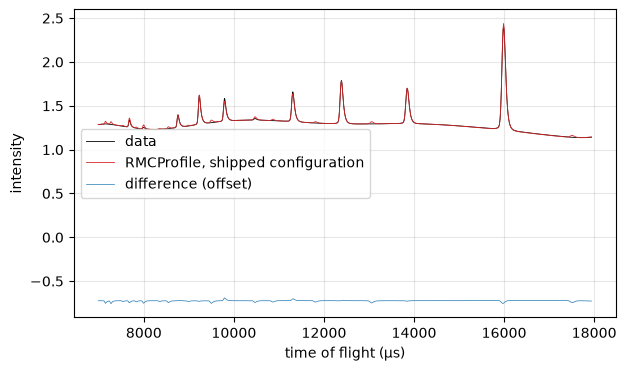

[PASS] the four Bragg input files parse (one bank of data, its background and instrument lines)
[PASS] RMCProfile evaluated the profile (a _bragg.csv with the data's point count)
[PASS] the shipped configuration already reproduces the profile (correlation > 0.99) — 0.9982


In [5]:
if not skip_without_package("the Bragg files of the shipped exercise"):
    work = os.path.join(WORK, "bragg_ex_1")
    ua.stage_exercise(PKG, "ex_1", work)
    stem = ua.EXERCISES["ex_1"].stem
    brg = rt.read_bragg(os.path.join(work, stem + ".bragg"))
    back = rt.read_back(os.path.join(work, stem + ".back"))
    inst = rt.read_inst(os.path.join(work, stem + ".inst"))
    hkl = rt.read_hkl(os.path.join(work, stem + ".hkl"))
    print(f".bragg: {brg.npoints} points of bank {brg.bank}, TOF {brg.x.min():.0f}–{brg.x.max():.0f} µs, scale {brg.scale}")
    print(f".back: {len(back)} background coefficients; .inst: {len(inst)} bank(s), {len(inst[0]['values'])} values; .hkl: {hkl}")
    d = rt.read_dat(os.path.join(work, stem + ".dat"))
    print("BRAGG block keywords:", [k for k, _ in next(b for b in d.blocks if b.name == "BRAGG").items])
    res = rt.run_rmcprofile(stem, work, PKG, timeout_min=5)
    t, calc, expt = rt.read_csv_pair(os.path.join(work, stem + "_bragg.csv"))
    corr_b = np.corrcoef(calc, expt)[0, 1]
    print("rc", res.returncode, "| chi2 rows:", {k: v for k, v in res.final_chi2.items() if "Bragg" in k or k == "chi2"}, f"| profile correlation {corr_b:.4f}")
    fig, ax = plt.subplots()
    ax.plot(t, expt, "k", lw=0.6, label="data")
    ax.plot(t, calc, "C3", lw=0.6, label="RMCProfile, shipped configuration")
    ax.plot(t, expt - calc - 0.3 * np.abs(expt).max(), "C0", lw=0.5, label="difference (offset)")
    ax.set_xlabel("time of flight (µs)"); ax.set_ylabel("intensity"); ax.legend()
    show(fig)
    caption("The Bragg profile of the package's SF₆ exercise (bank data, black) and RMCProfile's "
            "calculated profile for the shipped configuration (red), with their difference: "
            "the average structure of the 4 320-atom box, fitted together with G(r) and F(Q).")
    check("the four Bragg input files parse (one bank of data, its background and instrument lines)", brg.npoints > 0 and len(back) >= 1 and len(inst) >= 1)
    check("RMCProfile evaluated the profile (a _bragg.csv with the data's point count)", res.returncode == 0 and len(t) == brg.npoints)
    check("the shipped configuration already reproduces the profile (correlation > 0.99)", corr_b > 0.99, f"{corr_b:.4f}")

### Exercises for chapter 5

**5.1** Write the X-ray file for Sr, Ti and O and check that each `c` coefficient plus the
four `a` coefficients sums to Z within 0.1 electron.

**5.2** At which $Q$ does the X-ray weight of Na–Cl in NaCl exceed its neutron weight
(both normalised to one)? Read it off `xray_weights` and `neutron_weights`.

In [6]:
# 5.1
ok = True
for sym in ("Sr", "Ti", "O"):
    coef = rt.cromer_mann_4term(sym)
    z_fit = coef[0] + coef[2] + coef[4] + coef[6] + coef[8]
    print(f"{sym}: sum a + c = {z_fit:.3f}  (Z = {rt.ATOMIC_NUMBER[sym]})")
    ok &= abs(z_fit - rt.ATOMIC_NUMBER[sym]) < 0.1
check("5.1 the fitted coefficients reproduce Z for Sr, Ti and O", ok)

# 5.2
wn = w_n["Na-Cl"] / sum(w_n.values())
above = qq[w_x["Na-Cl"] > wn]
print(f"neutron Na–Cl weight {wn:.3f}; X-ray Na–Cl weight exceeds it {'for all Q up to %.1f' % above.max() if len(above) else 'nowhere'}")
check("5.2 the X-ray Na–Cl weight is above the neutron one at low Q", len(above) > 0 and above.min() < 1.0)

Sr: sum a + c = 37.986  (Z = 38)
Ti: sum a + c = 21.998  (Z = 22)
O: sum a + c = 8.000  (Z = 8)
[PASS] 5.1 the fitted coefficients reproduce Z for Sr, Ti and O
neutron Na–Cl weight 0.399; X-ray Na–Cl weight exceeds it for all Q up to 25.0
[PASS] 5.2 the X-ray Na–Cl weight is above the neutron one at low Q


True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 5 — checks passed : {_CHECKS['pass']}")
print(f"chapter 5 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 5 — checks passed : 13
chapter 5 — checks failed : 0
wall time                 : 8 s
Every quantitative claim in this notebook was verified in this run.
